# Phase 1: Reading Brain Signals — EEG Preprocessing & Exploration

Every time you imagine moving your hand, a specific pattern of electrical activity shifts across your motor cortex, even if your hand never moves. A Brain-Computer Interface (BCI) is a system that reads that pattern and turns it into a command for a machine.

This project builds that chain end to end: decode imagined movement from real EEG recordings, smooth the noisy predictions with a Kalman filter, and use them to drive a simulated robotic arm. This first notebook covers the foundation: what an EEG signal actually is, how to clean it, and what imagined movement looks like in the data.

Unlike the orbital project, this uses **real recordings from real people**, not simulated data. That means noise, variation between subjects, and results that won't be perfectly clean. That's the realistic version of the problem.


In [2]:
import numpy as np                    # numerical arrays for signal data
import matplotlib.pyplot as plt       # plotting raw and filtered signals
import mne                            # loading and processing EEG recordings
from mne.datasets import eegbci       # PhysioNet motor imagery dataset loader
from mne.io import concatenate_raws, read_raw_edf   # reading and combining EEG recording files

np.random.seed(42)
mne.set_log_level("WARNING")          # keeps MNE's output quiet
print(f"MNE version: {mne.__version__}")

MNE version: 1.13.2


In [3]:
# Downloads (first run only) and loads subject 1's imagined left/right fist recordings
subject = 1
imagery_runs = [4, 8, 12]   # runs where the subject imagines opening/closing the left or right fist

file_paths = eegbci.load_data(subject, imagery_runs)
raws = [read_raw_edf(path, preload=True) for path in file_paths]
raw = concatenate_raws(raws)

eegbci.standardize(raw)                                   # cleans up electrode names
raw.set_montage(mne.channels.make_standard_montage("standard_1005"))   # assigns 3D scalp positions

print(f"Sampling rate: {raw.info['sfreq']} Hz")
print(f"Number of EEG channels: {len(raw.ch_names)}")
print(f"Recording length: {raw.times[-1]:.0f} seconds")
print(f"Event labels in the recording: {sorted(set(raw.annotations.description))}")

Sampling rate: 160.0 Hz
Number of EEG channels: 64
Recording length: 375 seconds
Event labels in the recording: ['BAD boundary', 'EDGE boundary', 'T0', 'T1', 'T2']


/Users/victordeni/brain-controlled-robotic-arm/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/5c/tbs3rzhx5nld4zff5wp02ywh0000gn/T/ipykernel_81895/1194254829.py:10: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  raw.set_montage(mne.channels.make_standard_montage("standard_1005"))   # assigns 3D scalp positions


## Step 2: Where the Sensors Sit

Each of the 64 electrodes sits at a standard position on the scalp. The ones that matter most for this project are over the **motor cortex**, the strip of brain that controls movement:

- **C3**: left side, controls the *right* hand
- **Cz**: center, controls the feet
- **C4**: right side, controls the *left* hand

The brain is crossed: imagining a left-hand movement activates the *right* side of the motor cortex, and vice versa. That asymmetry between C3 and C4 is the main signal a classifier can use.

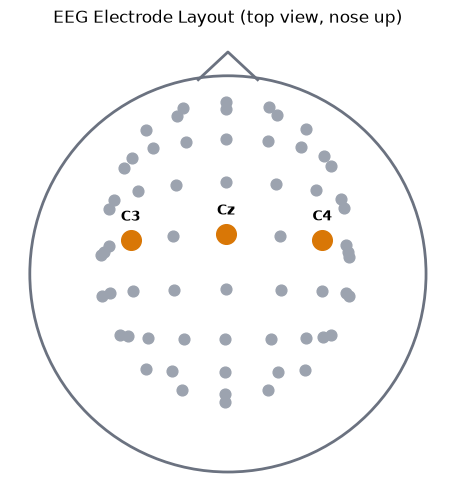

In [4]:
# Draws a top-down view of the 64 electrode positions, highlighting the motor cortex channels
pos = raw.get_montage().get_positions()["ch_pos"]
xy = np.array([pos[name][:2] for name in raw.ch_names])
motor_channels = ["C3", "Cz", "C4"]

radius = np.abs(xy).max() * 1.15
fig, ax = plt.subplots(figsize=(6, 6))
ax.add_patch(plt.Circle((0, 0), radius, fill=False, color="#6b7280", linewidth=2))
ax.plot([-radius * 0.15, 0, radius * 0.15], [radius * 0.98, radius * 1.12, radius * 0.98], color="#6b7280", linewidth=2)  # nose

ax.scatter(xy[:, 0], xy[:, 1], s=60, color="#9ca3af", label="Other electrodes")
for name in motor_channels:
    ax.scatter(*pos[name][:2], s=200, color="#d97706", zorder=3)
    ax.annotate(name, pos[name][:2], textcoords="offset points", xytext=(0, 14), ha="center", fontweight="bold")

ax.set_title("EEG Electrode Layout (top view, nose up)")
ax.set_aspect("equal")
ax.axis("off")
plt.show()

## Step 3: What Raw EEG Actually Looks Like

Here are 30 seconds of raw signal from the three motor cortex electrodes, with the imagined-movement periods shaded: blue for **left fist** (T1) and green for **right fist** (T2). Unshaded stretches are rest.

Don't expect to spot the difference by eye. EEG amplitudes are tiny, tens of microvolts (millionths of a volt), and dominated by noise: muscle twitches, eye blinks, electrical interference from the wall outlet, and slow drift. Cleaning that up is what the next step is for.
![EEG recording](../images/eeg_recording_chain.png)

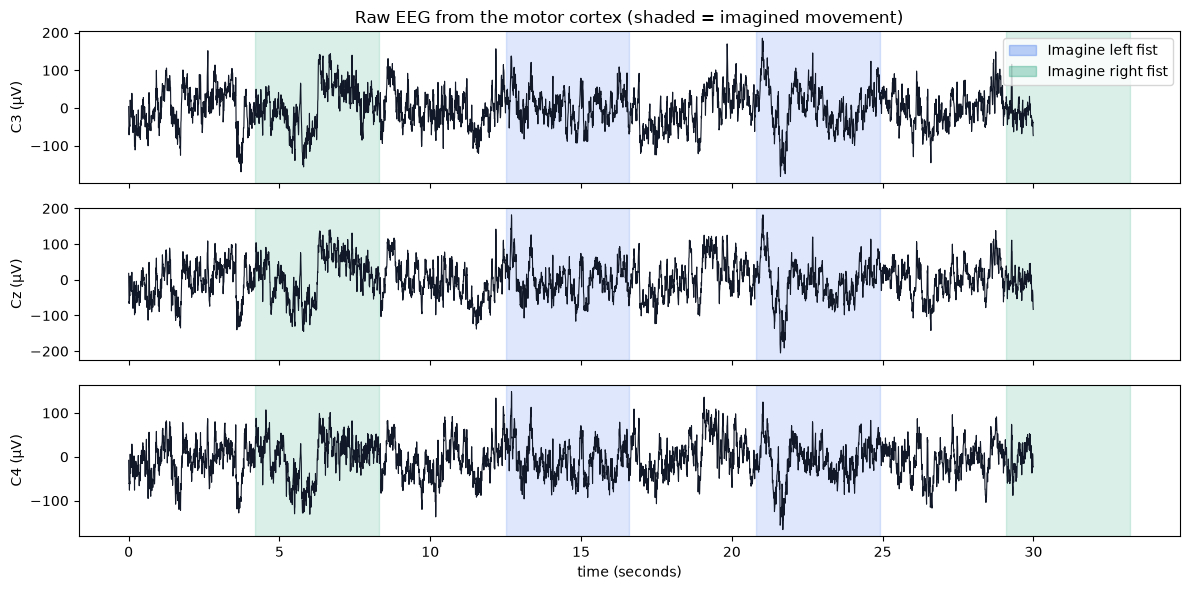

In [5]:
# Plots 30 seconds of raw signal from the three motor cortex channels, shading imagined-movement periods
from matplotlib.patches import Patch

start, stop = 0, 30
sfreq = raw.info["sfreq"]
channels = ["C3", "Cz", "C4"]
data, times = raw[channels, int(start * sfreq):int(stop * sfreq)]
data_uv = data * 1e6   # volts -> microvolts

shade_colors = {"T1": "#2563eb", "T2": "#059669"}
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
for ax, trace, name in zip(axes, data_uv, channels):
    ax.plot(times, trace, color="#111827", linewidth=0.8)
    ax.set_ylabel(f"{name} (µV)")
    for onset, duration, desc in zip(raw.annotations.onset, raw.annotations.duration, raw.annotations.description):
        onset = onset - raw.first_time
        if desc in shade_colors and onset < stop and onset + duration > start:
            ax.axvspan(onset, onset + duration, color=shade_colors[desc], alpha=0.15)

axes[-1].set_xlabel("time (seconds)")
axes[0].set_title("Raw EEG from the motor cortex (shaded = imagined movement)")
axes[0].legend(handles=[Patch(color="#2563eb", alpha=0.3, label="Imagine left fist"),
                        Patch(color="#059669", alpha=0.3, label="Imagine right fist")], loc="upper right")
plt.tight_layout()
plt.show()

## Step 4: Filtering Out the Noise

Brain activity oscillates at different speeds, and different speeds mean different things. The two bands that matter for movement are:

- **Mu rhythm (8–13 Hz)**: a steady oscillation over the motor cortex while the body is at rest
- **Beta rhythm (13–30 Hz)**: faster activity linked to motor control

When you move a hand, or just *imagine* moving it, the mu rhythm over the opposite side of the motor cortex weakens. This is called **event-related desynchronization (ERD)**. Imagine your left fist and mu power drops over C4 (right hemisphere); imagine your right fist and it drops over C3. That drop is the signal a classifier can learn.

To isolate it, we apply a **bandpass filter** that keeps only 8–30 Hz and discards everything else: slow drift below 8 Hz, and muscle and electrical noise above 30 Hz.

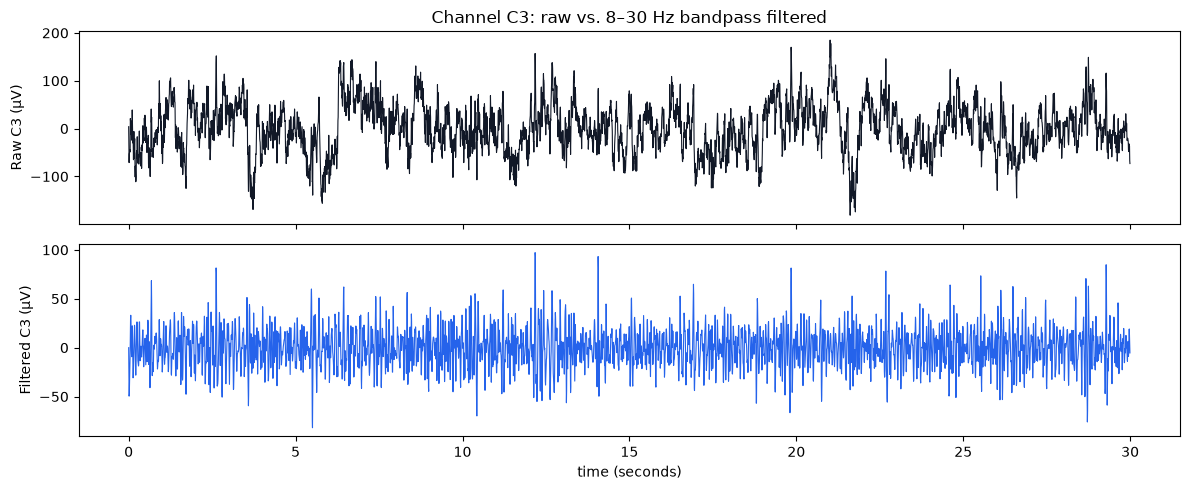

In [6]:
# Applies an 8-30 Hz bandpass filter and compares raw vs. filtered signal on channel C3
raw_filt = raw.copy().filter(l_freq=8.0, h_freq=30.0, verbose=False)

start, stop = 0, 30
sfreq = raw.info["sfreq"]
window = slice(int(start * sfreq), int(stop * sfreq))
raw_c3, times = raw[["C3"], window]
filt_c3, _ = raw_filt[["C3"], window]

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(times, raw_c3[0] * 1e6, color="#111827", linewidth=0.8)
axes[0].set_ylabel("Raw C3 (µV)")
axes[1].plot(times, filt_c3[0] * 1e6, color="#2563eb", linewidth=0.8)
axes[1].set_ylabel("Filtered C3 (µV)")
axes[1].set_xlabel("time (seconds)")
axes[0].set_title("Channel C3: raw vs. 8–30 Hz bandpass filtered")
plt.tight_layout()
plt.show()

## Step 5: Cutting the Recording into Trials

So far we've been looking at one continuous 6-minute recording. A classifier needs individual **trials**: short, labeled snippets, each one a single imagined movement.

We cut an **epoch** around every cue marker: from 1 second *before* the cue (a resting baseline) to 4 seconds *after* it (the imagined movement). Each epoch is labeled **left** (T1) or **right** (T2). This is the raw material for everything that follows.

In [7]:
# Cuts the filtered recording into labeled trials: 1 s before to 4 s after each left/right cue
events, _ = mne.events_from_annotations(raw_filt, event_id={"T1": 2, "T2": 3}, verbose=False)

epochs = mne.Epochs(
    raw_filt, events, event_id={"left": 2, "right": 3},
    tmin=-1.0, tmax=4.0, baseline=None, picks="eeg",
    preload=True, verbose=False,
)

print(f"Total trials: {len(epochs)}")
print(f"  Left-fist trials:  {len(epochs['left'])}")
print(f"  Right-fist trials: {len(epochs['right'])}")
print(f"Data shape (trials, channels, time samples): {epochs.get_data().shape}")

Total trials: 45
  Left-fist trials:  23
  Right-fist trials: 22
Data shape (trials, channels, time samples): (45, 64, 801)


## Step 6: Watching the Brain "Turn Down" (ERD)

To see the effect, we measure **how strong** the 8–30 Hz oscillation is at every moment (its power), average that across all trials of the same type, and express it as a percentage change from the 1-second resting baseline before the cue.

The prediction from the motor cortex's crossed wiring:

- **C3** (left hemisphere) should dip when imagining the **right** fist
- **C4** (right hemisphere) should dip when imagining the **left** fist

A dip below 0% is the event-related desynchronization (ERD). With only about 22 trials per class, expect a noisy version of the textbook picture, which is part of working with real data.

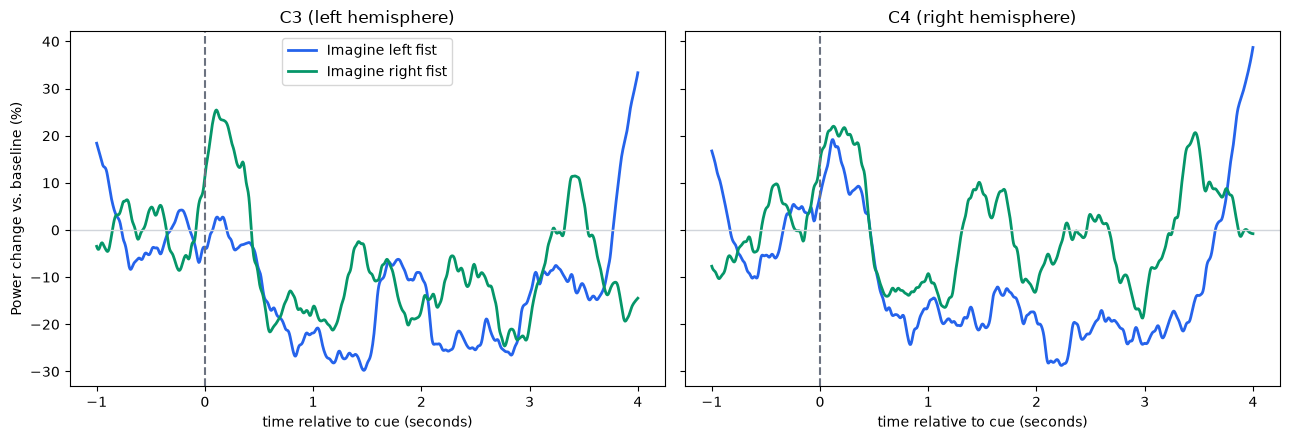

In [8]:
# Computes and plots average band-power change (ERD) over C3 and C4 for left vs. right imagery
from scipy.ndimage import uniform_filter1d   # smooths the curves with a moving average

sfreq = raw.info["sfreq"]

# Oscillation strength at every moment: Hilbert envelope of the filtered signal, squared
raw_env = raw_filt.copy().pick(["C3", "C4"]).apply_hilbert(envelope=True, verbose=False)
epochs_env = mne.Epochs(raw_env, events, event_id={"left": 2, "right": 3},
                        tmin=-1.0, tmax=4.0, baseline=None, preload=True, verbose=False)
times = epochs_env.times

def erd_percent(label, channel):
    power = epochs_env[label].get_data(picks=channel)[:, 0, :] ** 2   # (trials, time)
    mean_power = power.mean(axis=0)
    smooth = uniform_filter1d(mean_power, size=int(0.5 * sfreq), mode="nearest")
    baseline = smooth[times < 0].mean()
    return (smooth - baseline) / baseline * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, channel, title in zip(axes, ["C3", "C4"], ["C3 (left hemisphere)", "C4 (right hemisphere)"]):
    ax.plot(times, erd_percent("left", channel), color="#2563eb", linewidth=2, label="Imagine left fist")
    ax.plot(times, erd_percent("right", channel), color="#059669", linewidth=2, label="Imagine right fist")
    ax.axvline(0, color="#6b7280", linestyle="--")
    ax.axhline(0, color="#d1d5db", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("time relative to cue (seconds)")
axes[0].set_ylabel("Power change vs. baseline (%)")
axes[0].legend()
plt.tight_layout()
plt.show()

## Reading the Result

The averaged plot shows three things:

- **Right after each cue**, power briefly jumps in every condition. That's the brain reacting to the cue appearing on screen, not to the imagined movement.
- **From about half a second after the cue**, power drops 20–30% below the resting baseline and stays down for most of the trial. This is event-related desynchronization (ERD), the signature of the motor cortex becoming active during imagined movement.
- **The drop appears on both sides of the brain**, with a modest lateral effect on top: over C4, imagining the left fist produces a deeper drop than imagining the right, matching the crossed-wiring prediction. Over C3 the difference is less clear.

**Takeaway:** the signal is real, but the left-vs-right difference is subtle and noisy. That's what we should expect from one subject and about 22 trials per class, and it's the honest reality of real-world EEG. Phase 2 builds a classifier that uses all 64 electrodes rather than hand-picking two, to extract as much of that difference as possible.

We now have 45 clean, labeled trials (23 left, 22 right) ready for classification.